In [1]:
import pandas as pd
import requests
import sqlite3

## Import Required Libraries

This step imports the Python libraries required for data analysis and data importing.

- pandas: used for data manipulation and analysis
- requests: used for API data extraction
- sqlite3: used for SQL database connection

## Import CSV Dataset

This step loads the sales dataset from the data folder into a pandas DataFrame using the `read_csv()` function.

## Preview Dataset

The `head()` function displays the first 5 rows of the dataset. This helps verify that the data has been imported correctly.

In [4]:
csv_data = pd.read_csv(
    "../data/Sample - Superstore.csv",
    encoding="latin1"
)

csv_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Information

The `info()` function provides an overview of the dataset structure, including:
- number of rows and columns
- column names
- data types
- missing values

In [5]:
csv_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## Statistical Summary

The `describe()` function generates summary statistics for numerical columns such as:
- mean
- minimum
- maximum
- standard deviation
- quartiles

In [6]:
csv_data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Column Names

The `columns` function displays all column names in the dataset. This helps understand the dataset structure before analysis.

In [7]:
csv_data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

## Dataset Shape

The `shape` function returns the total number of rows and columns in the dataset.

In [8]:
csv_data.shape

(9994, 21)

## Missing Values Analysis

This step checks for missing or null values in each column using:
- `isnull()`
- `sum()`

Identifying missing values is an important part of data cleaning.

In [9]:
csv_data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Unique Category Values

The `unique()` function displays distinct values from the Category column. This helps understand the different product categories available in the dataset.

In [10]:
csv_data["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

## Category Frequency Analysis

The `value_counts()` function counts how many times each category appears in the dataset.

In [11]:
csv_data["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

## Sales Analysis by Category

This analysis groups the dataset by product category and calculates the total sales for each category. The results help identify which category generates the highest revenue.

In [12]:
csv_data.groupby("Category")["Sales"].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

## Sort Categories by Total Sales

This step sorts product categories from highest to lowest sales using the `sort_values()` function.

In [13]:
csv_data.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

## Store Sales Analysis Results

This step stores the grouped sales analysis results into a new variable for further analysis and visualization.

In [15]:
category_sales = csv_data.groupby("Category")["Sales"].sum()

category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

## Sales Visualization by Category

This chart visualizes total sales for each product category to help identify the highest-performing category.

<Axes: xlabel='Category'>

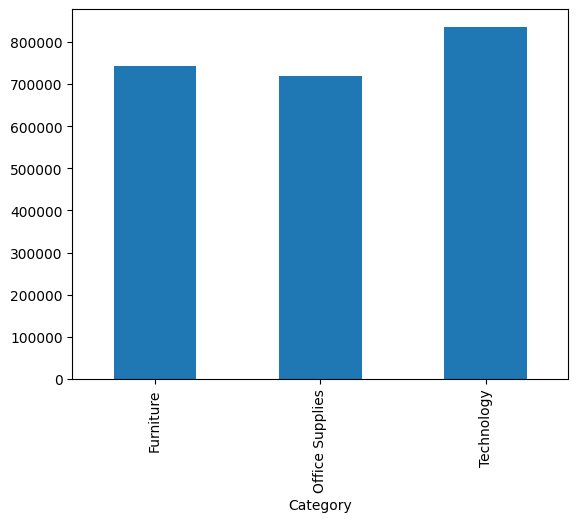

In [17]:
category_sales.plot(kind="bar")

## Customized Sales Visualization

This visualization improves chart readability by adding:
- chart title
- x-axis label
- y-axis label

Text(0, 0.5, 'Sales')

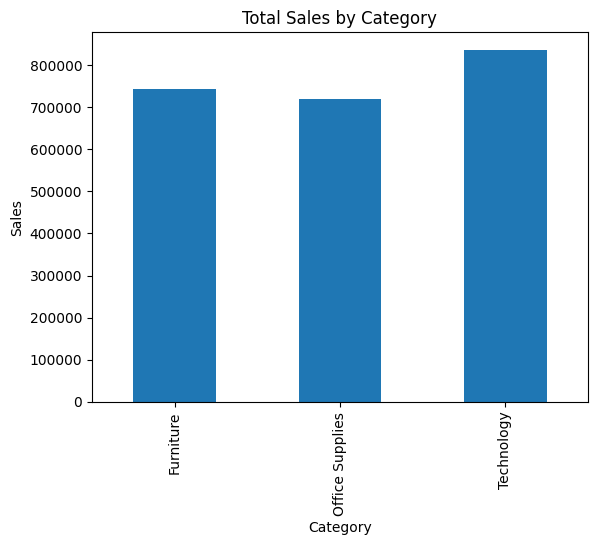

In [20]:
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

In [19]:
import matplotlib.pyplot as plt

In [ ]:
## Import Excel Dataset

This step imports data from an Excel file using the `read_excel()` function in pandas.

The dataset is loaded into a DataFrame for further exploration and analysis.

Additional libraries used:
- openpyxl for `.xlsx` files
- xlrd for `.xls` files

In [24]:
excel_data = pd.read_excel("../data/sampled.xls")

excel_data.head()

,0,First Name,Last Name,Gender,Country,Age,Date,Id
0,1,Dulce,Abril,Female,United States,32,15/10/2017,1562
1,2,Mara,Hashimoto,Female,Great Britain,25,16/08/2016,1582
2,3,Philip,Gent,Male,France,36,21/05/2015,2587
3,4,Kathleen,Hanner,Female,United States,25,15/10/2017,3549
4,5,Nereida,Magwood,Female,United States,58,16/08/2016,2468


In [25]:
excel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   0           50 non-null     int64
 1   First Name  50 non-null     str  
 2   Last Name   50 non-null     str  
 3   Gender      50 non-null     str  
 4   Country     50 non-null     str  
 5   Age         50 non-null     int64
 6   Date        50 non-null     str  
 7   Id          50 non-null     int64
dtypes: int64(3), str(5)
memory usage: 3.3 KB


In [26]:
excel_data.shape

(50, 8)

In [27]:
excel_data.columns

Index([0, 'First Name', 'Last Name', 'Gender', 'Country', 'Age', 'Date', 'Id'], dtype='object')

## Import JSON Dataset

This step imports data from a JSON file using the `read_json()` function in pandas.

JSON is a commonly used format for APIs and web-based data exchange.

In [28]:
json_data = pd.read_json("../data/schools.json")

json_data.head()

,name,address,phone,principal,grades,division
0,A. Henderson Elementary,"3799 Waterway Dr, Dumfries, VA 22025",703-670-2885,Ms. Suzanne Bevans,PK-5,Prince William County Public Schools
1,A.G. Richardson Elementary,"18370 Simms Dr, Culpeper, VA 22701",540-825-0616,Mrs. Susan E. Bridges,PK-5,Culpeper County Public Schools
2,A.M. Davis Elementary,"415 S Providence Rd, Richmond, VA 23236-3343",804-674-1310,Dr. Rachel Foglesong,PK-5,Chesterfield County Public Schools
3,A.P. Hill Elementary,"1450 Talley Avenue, Petersburg, VA 23803",804-862-7002,Mrs. Kori Reddick,KG-5,Petersburg Public Schools
4,A.S. Rhodes Elementary,"224 W Strasburg Rd, Front Royal, VA 22630",540-635-4556,Mrs. Doris S. Dean,KG-5,Warren County Public Schools


## Import Data from API

This step imports data from a public API using the `requests` library.

API data is commonly returned in JSON format and is widely used in modern data analytics workflows.

In [29]:
api_url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(api_url)

api_data = pd.DataFrame(response.json())

api_data.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


## Import Data from SQL Database

This section demonstrates importing data from a SQLite database using SQL queries and pandas.

In [30]:
connection = sqlite3.connect("../database/sales_data.db")

## Store Dataset into SQL Database

This step stores the CSV dataset into a SQLite database table using the `to_sql()` function in pandas.

The dataset is written into the `sales_table` table inside the `sales_data.db` database file.

Parameters used:
- `if_exists="replace"` replaces the table if it already exists
- `index=False` prevents pandas index values from being stored as an extra column

In [31]:
csv_data.to_sql(
    "sales_table",
    connection,
    if_exists="replace",
    index=False
)

9994

## Read Data from SQL Database

This step retrieves data from the SQLite database using an SQL query and loads the results into a pandas DataFrame.

The SQL query selects all records from the `sales_table` table for further analysis and exploration.

In [32]:
query = "SELECT * FROM sales_table"

sql_data = pd.read_sql(query, connection)

sql_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
